# ENVS 117 Exercise 1: Setting Up Your Python Toolkit

**Name:** *Asha LaManque*

**Today's goals**
1. Confirm that Python and Anaconda are working on your computer.
2. Learn how Jupyter notebooks work: cells, Markdown, and execution order.
3. Run the *same* notebook in JupyterLab and in Google Colab and compare.
4. Save your work to GitHub.

**How to run a cell:** click inside it and press `Shift + Enter`.

## Part 1. Where am I running?

Run the cell below. Write down the output. You will run this same cell again in Google Colab later and compare.

In [1]:
import sys
import os
import platform

in_colab = "google.colab" in sys.modules

print("Running in Google Colab:", in_colab)
print("Python version:        ", platform.python_version())
print("Python executable:     ", sys.executable)
print("Operating system:      ", platform.system(), platform.release())

Running in Google Colab: False
Python version:         3.11.16
Python executable:      /opt/anaconda3/envs/envs117/bin/python
Operating system:       Darwin 25.6.0


## Part 2. Which packages do I have?

Packages are add-ons that give Python new abilities. Anaconda and Colab both come with many packages preinstalled, but not always the same ones or the same versions.

In [2]:
import numpy as np
import pandas as pd
import matplotlib

print(f"{'numpy':<12} {np.__version__}")
print(f"{'pandas':<12} {pd.__version__}")
print(f"{'matplotlib':<12} {matplotlib.__version__}")

# geopandas is the main package we will use for vector GIS data.
# It may or may not be installed yet. Either result is fine today.
try:
    import geopandas as gpd
    print(f"{'geopandas':<12} {gpd.__version__}")
except ImportError:
    print("geopandas is NOT installed in this environment (that is OK for today)")

numpy        2.4.6
pandas       3.0.6
matplotlib   3.11.2
geopandas    1.1.4


## Part 3. Where are my files?

Every notebook has a **working directory**: the folder Python looks in when you give it a file name. Most "file not found" errors come from being in a different folder than you think.

In [3]:
print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders here:")
for item in sorted(os.listdir(".")):
    print("  ", item)

Current working directory:
/Users/ranisaxena/Documents/ENVS117/week01

Files and folders here:
   .ipynb_checkpoints
   ENVS117_Ex1_Toolkit.ipynb


## Part 4. Markdown practice

This is a **Markdown cell**. It holds text, not code. Double-click to edit it, then press `Shift + Enter` to render it.

**Your turn:** replace the line below with one sentence about an environmental question you would like to answer with data.

*In general, one question might be: How have temperature and land surface changed in San Francisco over time?*

## Part 5. Execution order matters

Run the next three cells **in order** (A, then B, then C). Then go back and run **cell B again**. What changed, and why?

Originally, the printed-out temperature was from cell A (18 * 2 = 36). However, after running it again, it is from site_temp_c (Cell C) or 25 * 2.

In [4]:
# Cell A
site_temp_c = 18

In [5]:
# Cell B
print("Doubled temperature:", site_temp_c * 2)

Doubled temperature: 36


In [6]:
# Cell C
site_temp_c = 25

**Now try this:** from the menu, choose **Kernel > Restart Kernel and Run All Cells** (in Colab: **Runtime > Restart session and run all**). Look at the output of cell B again.

*What did you notice?* ...

The Doubled Temperature is from values in Cell A.

> Lesson: a notebook remembers what you **ran**, not what you **see** on the screen. Before you submit or share a notebook, always restart and run all cells from top to bottom.

## Part 6. A tiny environmental calculation

The rainfall numbers below are **made-up example values** for a hypothetical station with a Mediterranean climate (wet winters, dry summers), organized by water year (October to September).

Total water-year rainfall: 476 mm (18.7 in)
Wettest month: Sep


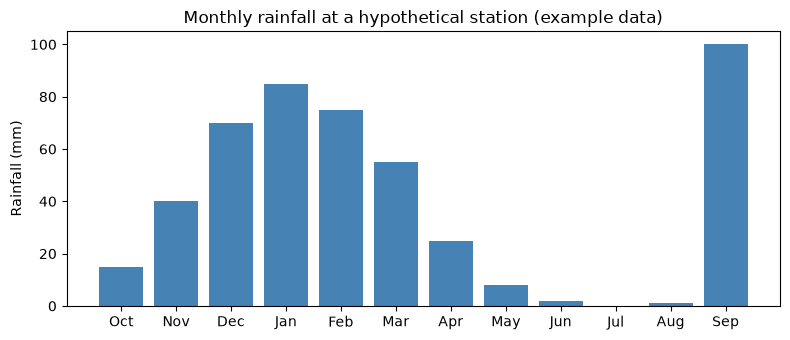

In [12]:
import matplotlib.pyplot as plt

months = ["Oct", "Nov", "Dec", "Jan", "Feb", "Mar",
          "Apr", "May", "Jun", "Jul", "Aug", "Sep"]
rain_mm = [15, 40, 70, 85, 75, 55, 25, 8, 2, 0, 1, 100]   # example values

total_mm = sum(rain_mm)
total_in = total_mm / 25.4
wettest = months[rain_mm.index(max(rain_mm))]

print(f"Total water-year rainfall: {total_mm} mm ({total_in:.1f} in)")
print(f"Wettest month: {wettest}")

plt.figure(figsize=(8, 3.5))
plt.bar(months, rain_mm, color="steelblue")
plt.ylabel("Rainfall (mm)")
plt.title("Monthly rainfall at a hypothetical station (example data)")
plt.tight_layout()
plt.show()

**Your turn:** change one or two values in `rain_mm` and re-run the cell. Does the total update? Does the chart update?

I changed the last value in the rain_mm list from 4 to 100 and noticed a difference. The total was previously 380 mm, and the chart displayed lower rainfall in Sept. When the value increased, the total is now 476mm, with Sept. having the highest rainfall.

## Part 7. Sneak peek at next week

Next week we cover variables, data types, and control flow. You do not need to understand every line yet. Just run it and guess what each line does.

The first line appears to be a dictionary. This links the city with the temperature. In the next line, it is a loop that covers all the temperatures. The temperatures are converted to Celsius and then labeled as "extreme heat", "warm", or "mild". The output is printed out. 

In [14]:
# Example daily high temperatures (made-up values), in degrees F
site_highs_f = {"Santa Clara": 78, "Fresno": 101, "Lake Tahoe": 64}

for site, temp_f in site_highs_f.items():
    temp_c = (temp_f - 32) * 5 / 9
    if temp_c >= 35:
        label = "extreme heat"
    elif temp_c >= 25:
        label = "warm"
    else:
        label = "mild"
    print(f"{site:<12} {temp_f} F = {temp_c:.1f} C  ->  {label}")

Santa Clara  78 F = 25.6 C  ->  warm
Fresno       101 F = 38.3 C  ->  extreme heat
Lake Tahoe   64 F = 17.8 C  ->  mild


## Part 8. Reflection (answer in this cell)

1. Compare your Part 1 and Part 2 output in JupyterLab vs. Google Colab. What was different?
2. In Part 5, why did cell B print different numbers?
3. Name one situation where you would choose Colab, and one where you would choose JupyterLab.

***1.** The outputs between JupyterLab and Google Colab contain different Python versions, executables, operating systems, and package versions (with the exception that they use geopandas 1.1.4). They also have different boolean outputs for the "Running in Google Colab:" prompt, where JupyterLab's output is False and Google Colab's output is True. 

JupyterLab Part 1 Output:

Running in Google Colab: False
Python version:         3.11.16
Python executable:      /opt/anaconda3/envs/envs117/bin/python
Operating system:       Darwin 25.6.0

JupyterLab Part 2 Output:
numpy        2.4.6
pandas       3.0.6
matplotlib   3.11.2
geopandas    1.1.4


Google Colab Part 1 Output:
Running in Google Colab: True
Python version:         3.13.15
Python executable:      /usr/bin/python3
Operating system:       Linux 6.6.122+

Google Colab Part 2 Output:
numpy        2.1.3
pandas       2.2.3
matplotlib   3.10.0
geopandas    1.1.4

***2.**  Cell B receives input from the most recently run cell. For example, when it was initially run, Cell A (value of 18) was used because it was run first. This is why the output initially displayed 18 * 2 = 36. However, after running Cell C (value of 25) and then Cell B, Cell B used Cell C's value. Thus, the output was 25 * 2 = 50. When I restarted the kernel and ran all cells, the value of Cell A was used because it was run before Cell C. 

***3.** Google Colab appears to require a lower barrier to entry, as it can be run from the browser and requires minimal command-line knowledge. It can also be used to more easily facilitate collaboration, as the same script can be shared. I would choose Google Colab for a smaller project where I need to collaborate with a wide variety of people (possibly with different skill levels or exposure to programming). I remember Google Colab was used in my biology class during the epidemiology unit to facilitate modeling data where group members could interact with the script simultaneously.

JupyterLab appears to be helpful with larger projects as it has a better file management system. In addition, it was mentioned that with Google Colab, packages need to be installed each time. JupyterLab allows you to use a virtual environment. While it may take slightly longer to set up and may require command-line knowledge, this is more helpful for larger projects. For example, I might consider using JupyterLab for a final project in this class, as it is more helpful for managing more documents/data.  

